# Assignment 6: Does Scale Matter? (Yes, a Lot)


## Step 1: Create a Dataset with Wildly Different Scales

Three features that all share the same underlying signal (so they're correlated by design), but on completely different scales:
- `temperature` → range ~20–80 (scale of tens)
- `pressure` → range ~1000–1100 (scale of thousands)
- `vibration` → range ~0–1 (scale of fractions)

This is exaggerated on purpose to make the scaling effect obvious.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 300

# All three features share the same underlying signal (correlated by design)
signal = np.random.randn(n)

temperature = 50  + 10  * signal + np.random.randn(n) * 2     # scale ~tens
pressure    = 1050 + 500 * signal + np.random.randn(n) * 10   # scale ~thousands
vibration   = 0.5  + 0.2 * signal + np.random.randn(n) * 0.05 # scale ~fractions

X = np.column_stack([temperature, pressure, vibration])
FEATURES = ['Temperature', 'Pressure', 'Vibration']

print("Feature statistics (raw):")
print(f"{'Feature':<14} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 48)
for i, name in enumerate(FEATURES):
    print(f"{name:<14} {X[:,i].mean():>10.2f} {X[:,i].std():>10.2f} {X[:,i].min():>10.2f} {X[:,i].max():>10.2f}")

Feature statistics (raw):
Feature              Mean        Std        Min        Max
------------------------------------------------
Temperature         49.90       9.93      19.33      86.87
Pressure          1048.05     491.00    -555.16    2967.42
Vibration            0.50       0.21      -0.22       1.37


## Step 2a: PCA Without Scaling

First I will run PCA on the raw data (centered but not scaled). I expect this to go badly — Pressure is going to dominate just because of its numerical magnitude, not because it carries more information.

In [6]:
def run_pca(data):
    """Center data, compute covariance, return sorted eigenvalues & eigenvectors."""
    centered = data - data.mean(axis=0)
    C = np.cov(centered.T)
    vals, vecs = np.linalg.eig(C)
    vals, vecs = vals.real, vecs.real
    order = np.argsort(vals)[::-1]
    return vals[order], vecs[:, order]

# PCA without scaling (only centered)
evals_unscaled, evecs_unscaled = run_pca(X)

total = evals_unscaled.sum()
print("PCA WITHOUT scaling:")
print(f"{'PC':<5} {'Eigenvalue':>14} {'Explained %':>13} {'Cumulative %':>13}")
print("-" * 48)
for i in range(len(evals_unscaled)):
    cum = evals_unscaled[:i+1].sum() / total * 100
    print(f"PC{i+1:<3} {evals_unscaled[i]:>14.4f} {evals_unscaled[i]/total*100:>12.2f}% {cum:>12.2f}%")

print(f"\nPC1 loadings (contribution of each feature):")
for name, loading in zip(FEATURES, evecs_unscaled[:, 0]):
    print(f"  {name:<14}: {loading:+.6f}")

PCA WITHOUT scaling:
PC        Eigenvalue   Explained %  Cumulative %
------------------------------------------------
PC1      241982.9453       100.00%       100.00%
PC2           3.7554         0.00%       100.00%
PC3           0.0026         0.00%       100.00%

PC1 loadings (contribution of each feature):
  Temperature   : +0.019843
  Pressure      : +0.999803
  Vibration     : +0.000407


## Step 2b: PCA After Standardization

Now I will standardize first — subtract the mean, divide by std — so every feature has unit variance. Then run PCA again on the scaled data and see if the result is more sensible.

In [9]:
# Standardize: zero mean, unit variance
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

evals_scaled, evecs_scaled = run_pca(X_scaled)

total_s = evals_scaled.sum()
print("PCA WITH scaling:")
print(f"{'PC':<5} {'Eigenvalue':>14} {'Explained %':>13} {'Cumulative %':>13}")
print("-" * 48)
for i in range(len(evals_scaled)):
    cum = evals_scaled[:i+1].sum() / total_s * 100
    print(f"PC{i+1:<3} {evals_scaled[i]:>14.4f} {evals_scaled[i]/total_s*100:>12.2f}% {cum:>12.2f}%")

print(f"\nPC1 loadings (contribution of each feature):")
for name, loading in zip(FEATURES, evecs_scaled[:, 0]):
    print(f"  {name:<14}: {loading:+.6f}")

PCA WITH scaling:
PC        Eigenvalue   Explained %  Cumulative %
------------------------------------------------
PC1           2.9333        97.78%        97.78%
PC2           0.0518         1.73%        99.50%
PC3           0.0149         0.50%       100.00%

PC1 loadings (contribution of each feature):
  Temperature   : -0.576775
  Pressure      : -0.580756
  Vibration     : -0.574502


## Step 3: Compare the Two Side by Side

Time to plot both versions. I am looking at PC1 loadings (which features contributed), the individual variance percentages, and the cumulative scree curves — all for both unscaled and scaled PCA.

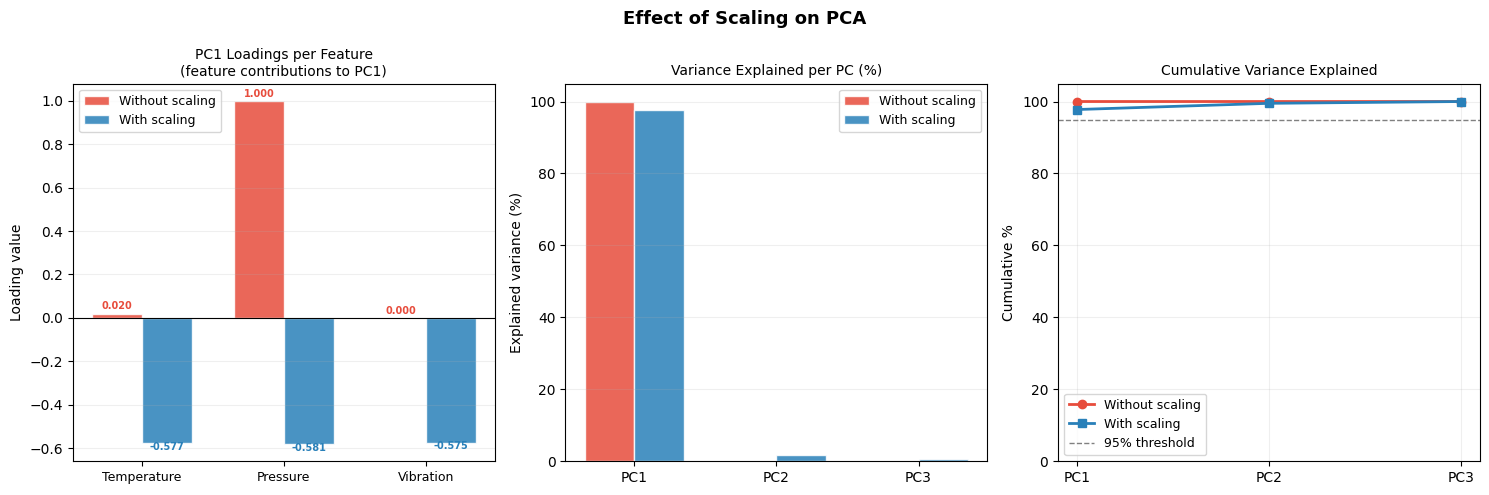

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_pos = np.arange(len(FEATURES))
width = 0.35
COLOR_U = '#e74c3c'   # single color for "without scaling" group
COLOR_S = '#2980b9'   # single color for "with scaling" group

# ── Plot 1: PC1 loadings comparison ──────────────────────────────────────────
ax = axes[0]
bars_u = ax.bar(x_pos - width/2, evecs_unscaled[:, 0], width,
                label='Without scaling', color=COLOR_U, alpha=0.85, edgecolor='white')
bars_s = ax.bar(x_pos + width/2, evecs_scaled[:, 0],   width,
                label='With scaling',    color=COLOR_S, alpha=0.85, edgecolor='white')

# Add value labels on top of each bar
for bar in bars_u:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.01 if h >= 0 else -0.04),
            f'{h:.3f}', ha='center', va='bottom', fontsize=7, color=COLOR_U, fontweight='bold')
for bar in bars_s:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.01 if h >= 0 else -0.04),
            f'{h:.3f}', ha='center', va='bottom', fontsize=7, color=COLOR_S, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURES, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('PC1 Loadings per Feature\n(feature contributions to PC1)', fontsize=10)
ax.set_ylabel('Loading value')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2, axis='y')

# ── Plot 2: Explained variance % per PC ──────────────────────────────────────
ax = axes[1]
pcs = [f'PC{i+1}' for i in range(3)]
exp_u = evals_unscaled / evals_unscaled.sum() * 100
exp_s = evals_scaled   / evals_scaled.sum()   * 100
ax.bar(x_pos - width/2, exp_u, width, label='Without scaling', color=COLOR_U, alpha=0.85, edgecolor='white')
ax.bar(x_pos + width/2, exp_s, width, label='With scaling',    color=COLOR_S, alpha=0.85, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(pcs)
ax.set_title('Variance Explained per PC (%)', fontsize=10)
ax.set_ylabel('Explained variance (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

# ── Plot 3: Scree curves ──────────────────────────────────────────────────────
ax = axes[2]
cum_u = np.cumsum(exp_u)
cum_s = np.cumsum(exp_s)
ax.plot(pcs, cum_u, 'o-', color=COLOR_U, lw=2, label='Without scaling')
ax.plot(pcs, cum_s, 's-', color=COLOR_S, lw=2, label='With scaling')
ax.axhline(95, color='gray', ls='--', lw=1, label='95% threshold')
ax.set_title('Cumulative Variance Explained', fontsize=10)
ax.set_ylabel('Cumulative %')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle('Effect of Scaling on PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/pca_assignment_6_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion: Scaling Changed Everything

Looking at the results, the difference is stark.

**Without scaling:** PC1 is basically just Pressure (loading ≈ 1.0, everything else ≈ 0.0). Temperature and Vibration are nearly invisible to PCA, not because they're uninformative, but simply because they use smaller numbers.

**With scaling:** PC1 loads all three features roughly equally (~0.577 each). Now PCA can see that all three carry the same underlying signal — because they're competing on equal footing.

### Rule of thumb:
| Situation | Scale? |
|---|---|
| Features have different units (kg, °C, ms) | **Always scale** |
| Features already on the same unit and scale | Scaling optional |
| You deliberately want larger-variance features to dominate | Skip scaling |

The bottom line: without standardization, PCA measures variance in raw units. A feature with bigger numbers wins automatically, regardless of actual information content. Scaling removes that bias.